In [1]:
import Computational_v2_borders as Computational
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
amount_of_components = 4
names = ['1_3491']
PCA_result = Computational.PCA_ICA(names = names, number_of_components = amount_of_components, if_use_ICA = False)

Explained_variance_ratio_by_each_component =  [0.81562067 0.09640412 0.032798   0.01576461]
Explained_variance_ratio =  0.960587398296791


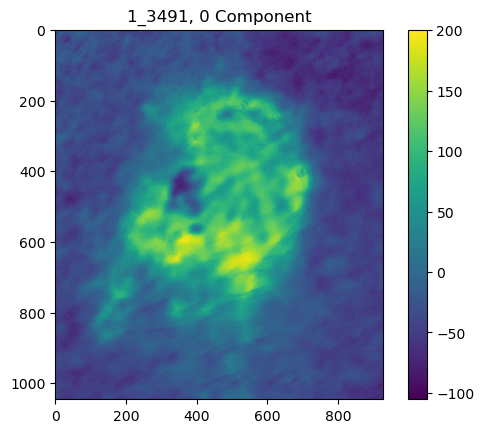

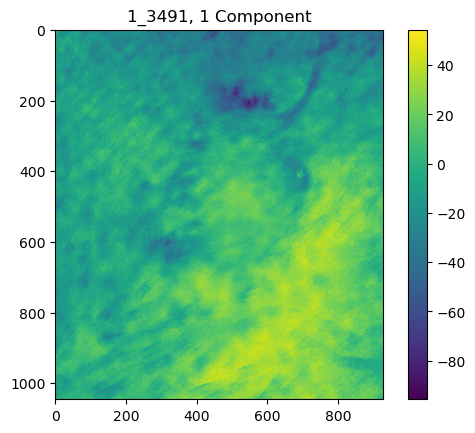

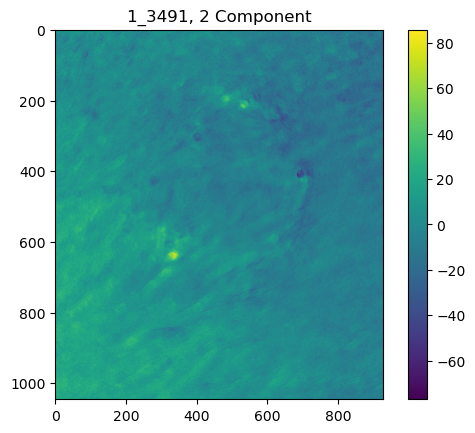

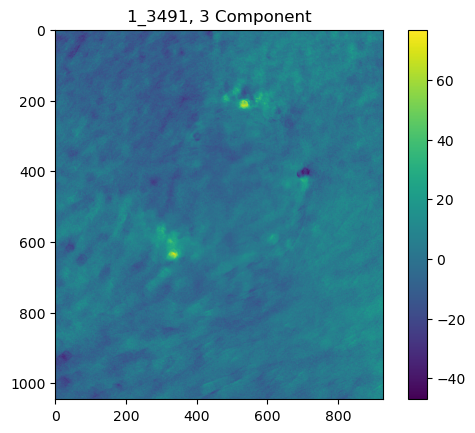

In [3]:
for name in names:
    for i in range(amount_of_components):
        plt.imshow(-PCA_result[name][:,:,i])
        plt.title(name+', '+str(i)+' Component')
        plt.colorbar()
        plt.show()

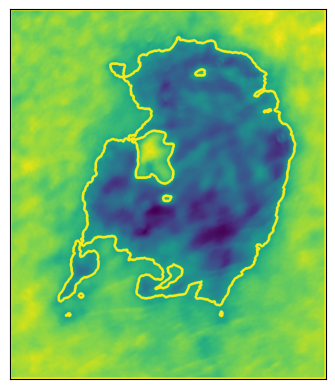

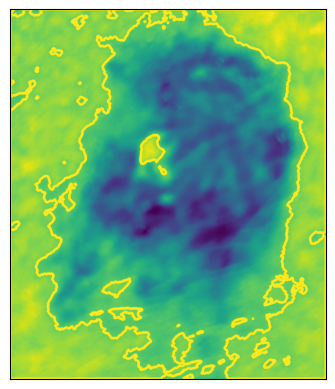

In [25]:
th1 = Computational.Offset_Percentage_Adjustment(dictionary_of_visits = PCA_result, 
                             name = names[0], 
                             which_component_to_use = 0, 
                             gaussian_blur = 2, 
                             offset_percent_1 = 0, 
                             offset_percent_2 = 35)

In [4]:
offset_percent_1 = [45]
offset_percent_2 = [35]
mean = {} 
std = {} 
area = {}
length = {}
thresholds = {}
skin = {}

In [5]:
for i in range(len(names)):
    thresholds[names[i]] = Computational.print_borders_thresholds(dictionary_of_visits = PCA_result, 
                                    name = names[i], 
                                    which_component_to_use = 0,
                                    gaussian_blur = 2, 
                                    offset_percent_1 = offset_percent_1[i], 
                                    offset_percent_2 = offset_percent_2[i], 
                                    step = 1, 
                                    show_pic = False)
    print(thresholds[names[i]])

(81.95, 201.15, 149.0)


In [6]:
dict_new = {k: -v for k, v in PCA_result.items()}


In [7]:
for i in range(len(names)):
    mean[i], std[i], area[i], length[i] = Computational.Borders_values(dictionary_of_visits = dict_new,                     
                                    offset_percent_1 = offset_percent_1[i], offset_percent_2 = offset_percent_2[i],  
                                    name = names[i], 
                                    which_component_to_use = 0,
                                    gaussian_blur = 2, 
                                    step = 1)
    
    
    skin[i] = Computational.extract_skin_value(dictionary_of_visits = dict_new, 
                                    name = names[i], 
                                    which_component_to_use = 0,
                                    gaussian_blur = 2, 
                                    offset_percent_1 = offset_percent_1[i])

100%|████████████████████████████████████████████████████████████████████████████████| 198/198 [06:52<00:00,  2.08s/it]


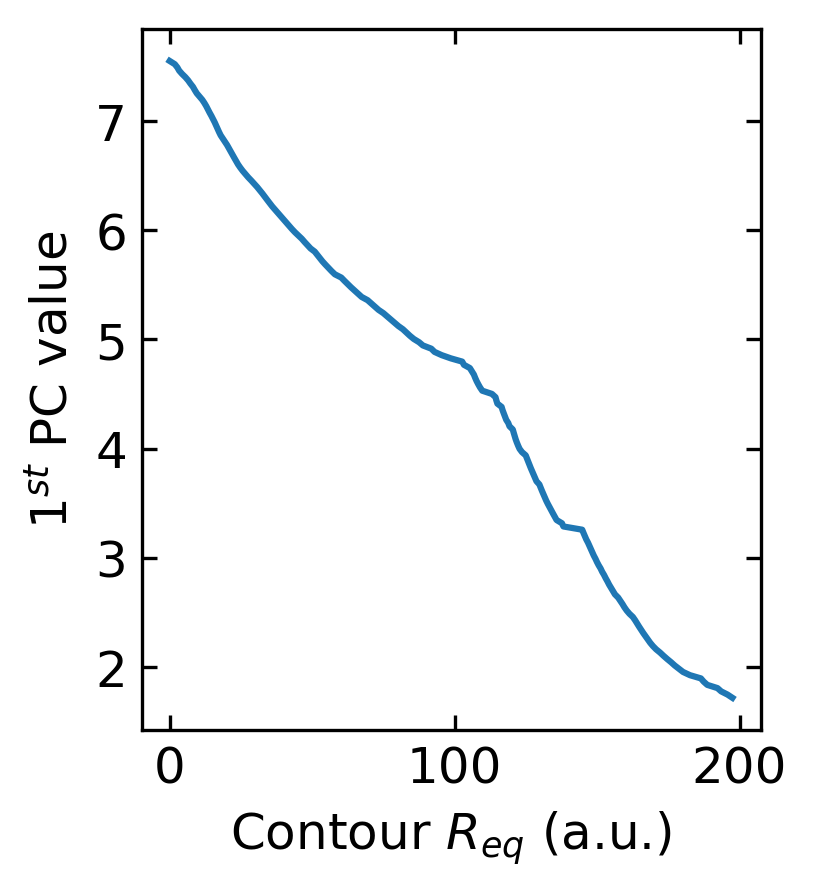

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# set global font size to 12
plt.rcParams.update({'font.size': 12})

# create a 12 cm × 12 cm figure (12 cm ≃ 12/2.54 in) at 300 dpi
fig, ax = plt.subplots(dpi=300, figsize=(7.313/2.54, 8/2.54))

for i in range(len(names)):
    ax.plot(
        np.sqrt(np.array(area[i]) / (4*np.pi)),
        mean[i] / skin[i],
        # no label → no legend
    )

ax.set_xlabel(r'Contour $R_{eq}$ (a.u.)')
ax.set_ylabel(r'$1^{st}$ PC value')

# ticks pointing in, with top/right ticks on
ax.tick_params(
    axis='both',
    which='both',
    direction='in',
    top=True,
    right=True
)

# square aspect ratio
ax.set_aspect('auto')
plt.tight_layout()
plt.savefig("figure 1d.pdf")
plt.show()

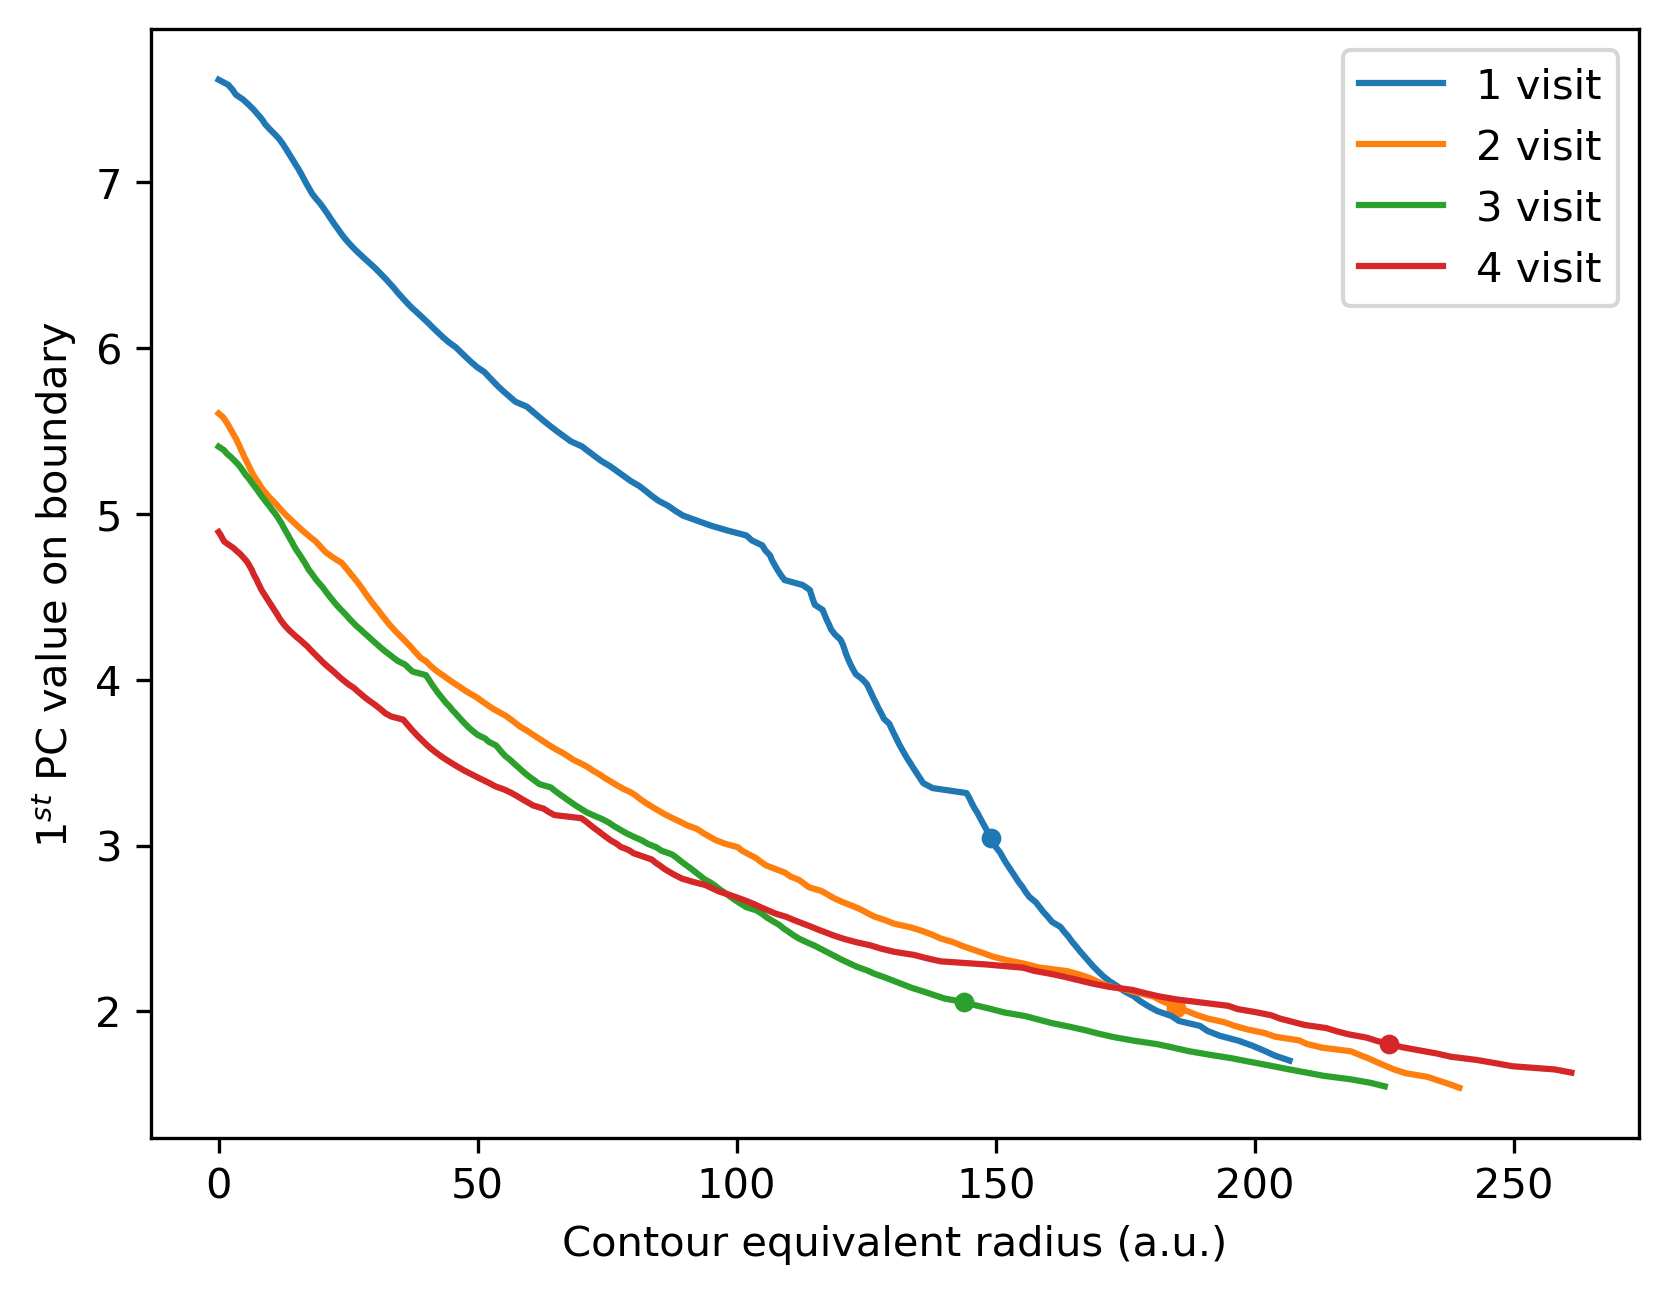

In [10]:
plt.figure(dpi = 300)
for i in range(len(names)):
    p = plt.plot(np.sqrt(np.array(area[i])/4/np.pi), mean[i]/skin[i], label = str(i+1) + ' visit')

    plt.scatter(np.sqrt(np.array(area[i])/4/np.pi)[np.absolute(np.array(mean[i]) - thresholds[names[i]][2]).argmin()], 
                thresholds[names[i]][2]/skin[i],
               color = p[-1].get_color(), marker = 'o', s = 14)

plt.xlabel('Contour equivalent radius (a.u.)')
plt.ylabel('$1^{st}$ PC value on boundary')
plt.legend()

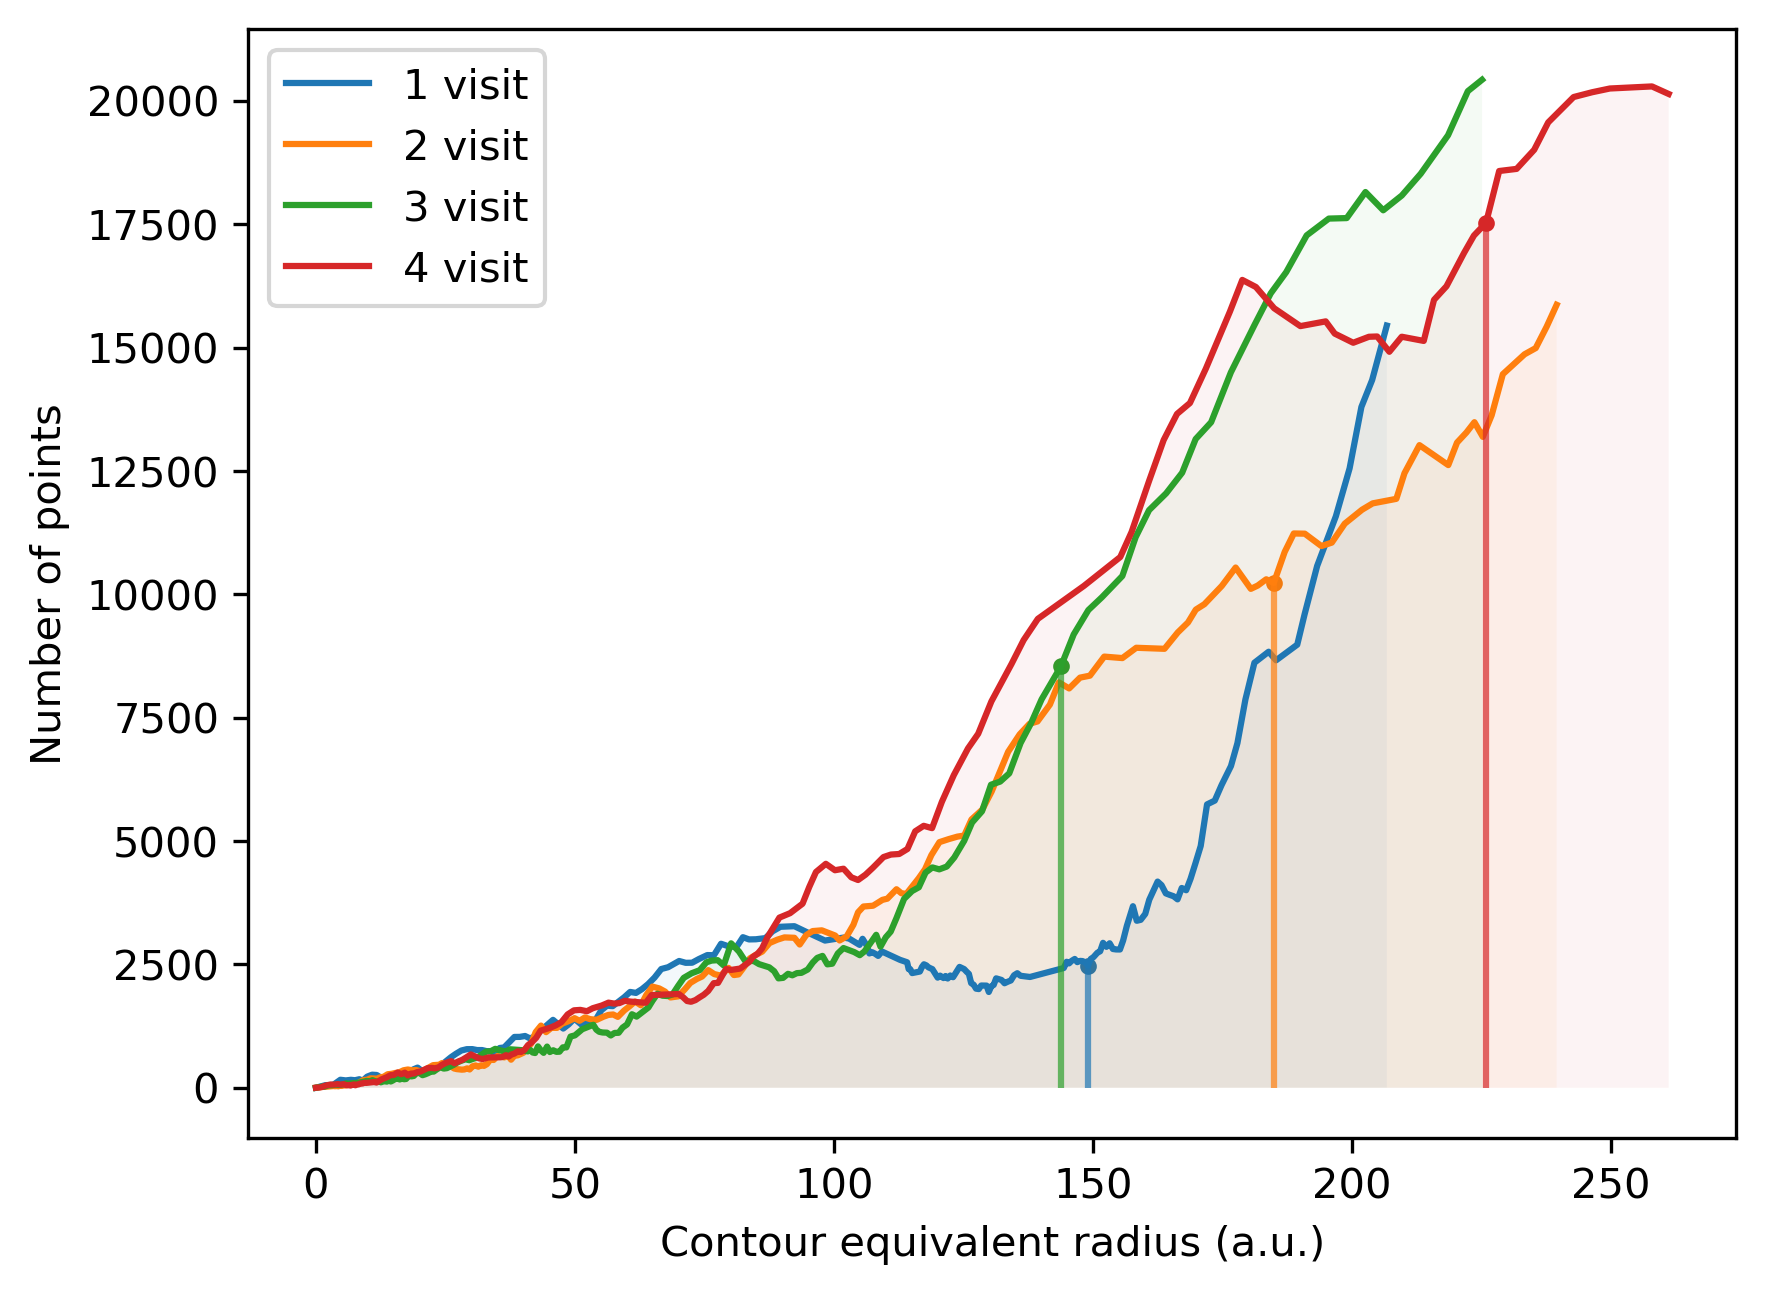

In [11]:
plt.figure(dpi = 300)
for i in range(len(names)):
    p = plt.plot(np.sqrt(np.array(area[i])/4/np.pi), length[i], label = str(i+1) + ' visit')

    plt.fill_between(np.sqrt(np.array(area[i])/4/np.pi), length[i], 0, alpha = 0.05)

#     plt.vlines(np.sqrt(np.array(area[i])/4/np.pi)[np.absolute(np.array(mean[i]) - thresholds[names[i]][1]).argmin()], 0, 
#                length[i][np.absolute(np.array(mean[i]) - thresholds[names[i]][1]).argmin()], 
#                color = p[-1].get_color(), alpha = 0.7, ls = '-')
#     plt.scatter(np.sqrt(np.array(area[i])/4/np.pi)[np.absolute(np.array(mean[i]) - thresholds[names[i]][1]).argmin()],
#                length[i][np.absolute(np.array(mean[i]) - thresholds[names[i]][1]).argmin()], 
#                color = p[-1].get_color(), marker = '.')
    

    plt.vlines(np.sqrt(np.array(area[i])/4/np.pi)[np.absolute(np.array(mean[i]) - thresholds[names[i]][2]).argmin()], 0, 
               length[i][np.absolute(np.array(mean[i]) - thresholds[names[i]][2]).argmin()], 
               color = p[-1].get_color(), alpha = 0.7, ls = '-')
    plt.scatter(np.sqrt(np.array(area[i])/4/np.pi)[np.absolute(np.array(mean[i]) - thresholds[names[i]][2]).argmin()],
               length[i][np.absolute(np.array(mean[i]) - thresholds[names[i]][2]).argmin()], 
               color = p[-1].get_color(), marker = '.')


plt.xlabel('Contour equivalent radius (a.u.)')
plt.ylabel('Number of points')
plt.legend()

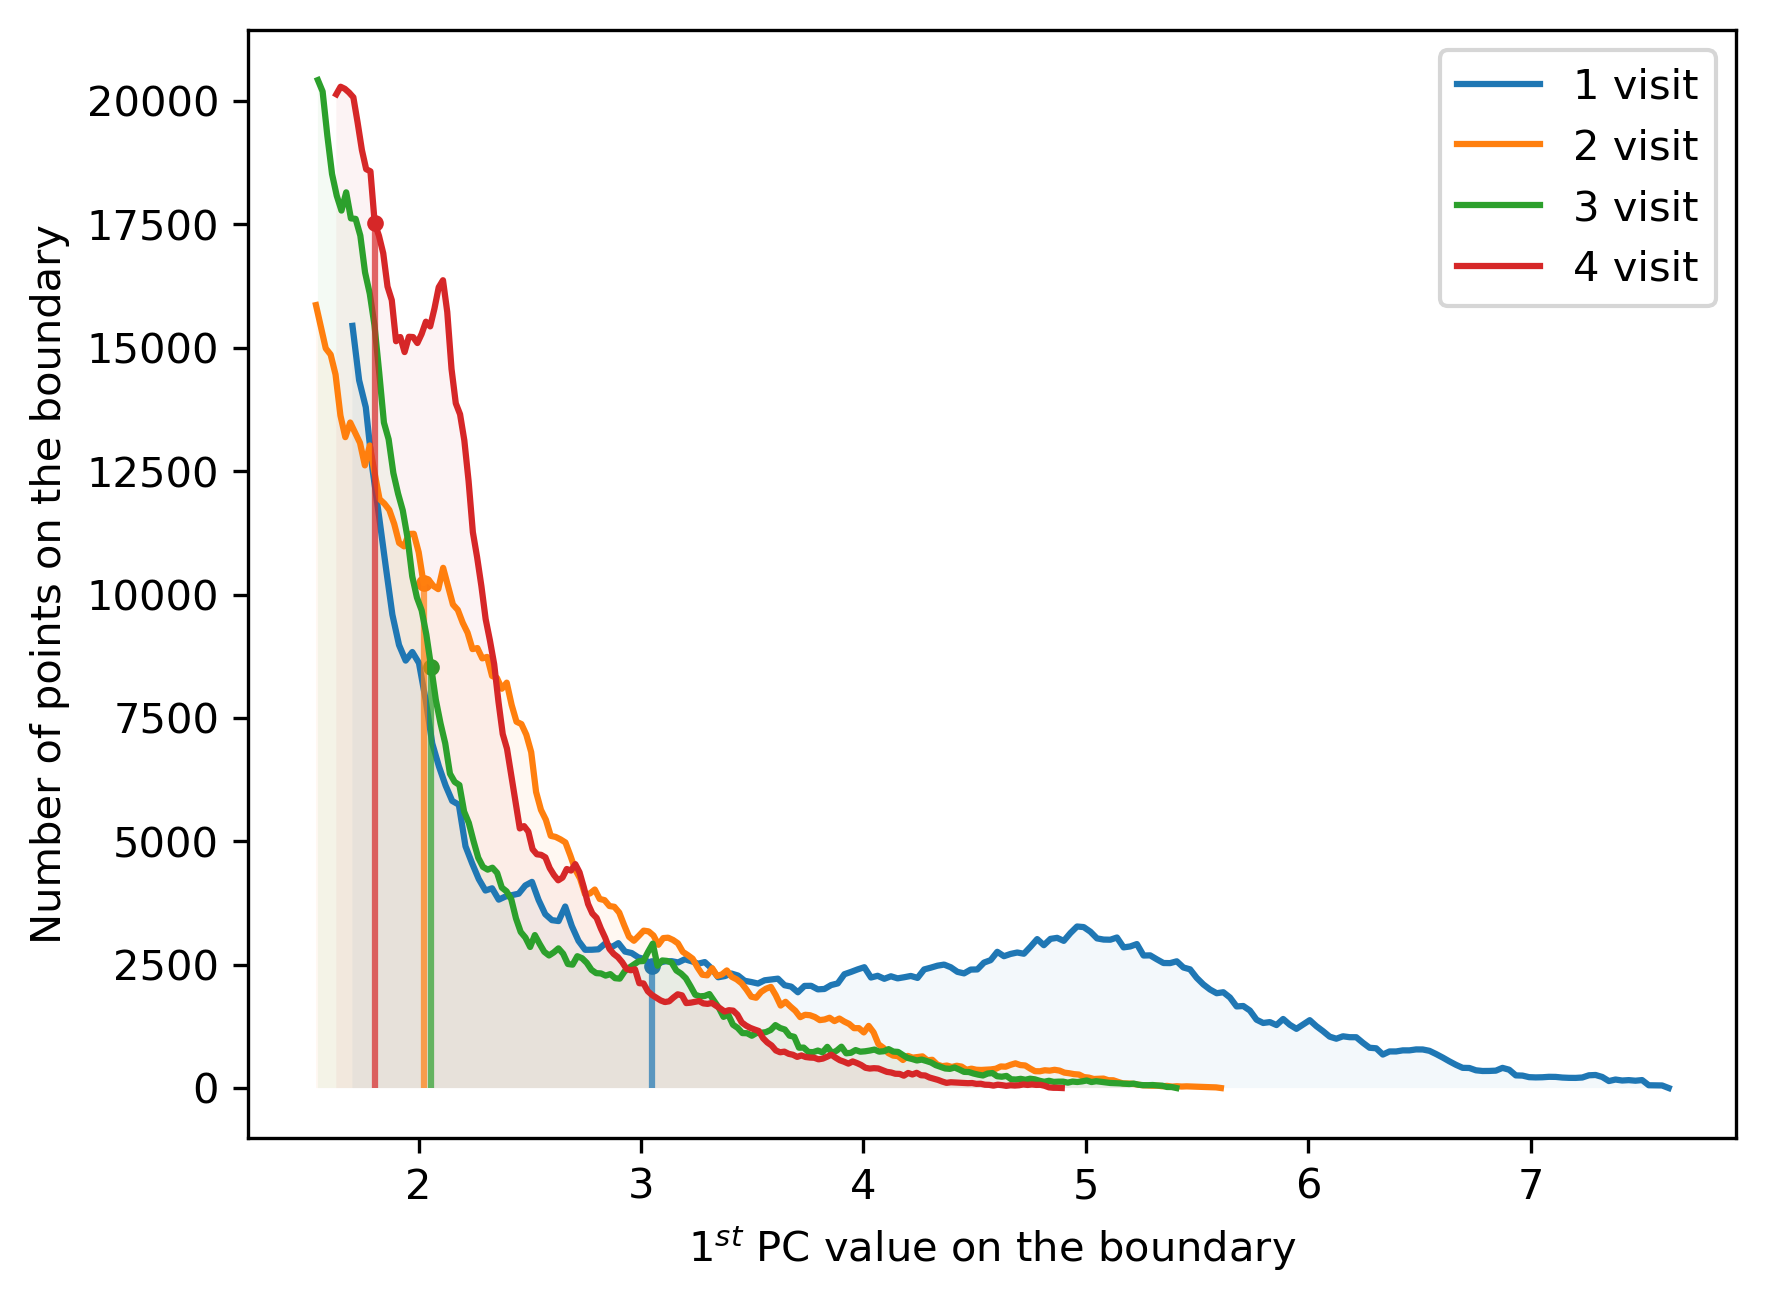

In [12]:
plt.figure(dpi = 300)
for i in range(len(names)):
    p = plt.plot(mean[i]/skin[i], length[i], label = str(i+1) + ' visit')

    plt.fill_between(mean[i]/skin[i], length[i], 0, alpha = 0.05)
    
    
#     plt.vlines(thresholds[names[i]][1]/skin[i], 0, 
#                length[i][np.absolute(np.array(mean[i]) - thresholds[names[i]][1]).argmin()], 
#                color = p[-1].get_color(), alpha = 0.7, ls = '-')
#     plt.scatter(thresholds[names[i]][1]/skin[i],
#                length[i][np.absolute(np.array(mean[i]) - thresholds[names[i]][1]).argmin()], 
#                color = p[-1].get_color(), marker = '.')
    
    
    plt.vlines(thresholds[names[i]][2]/skin[i], 0, 
               length[i][np.absolute(np.array(mean[i]) - thresholds[names[i]][2]).argmin()], 
               color = p[-1].get_color(), alpha = 0.7, ls = '-')
    plt.scatter(thresholds[names[i]][2]/skin[i],
               length[i][np.absolute(np.array(mean[i]) - thresholds[names[i]][2]).argmin()], 
               color = p[-1].get_color(), marker = '.')
    


plt.xlabel('$1^{st}$ PC value on the boundary')
plt.ylabel('Number of points on the boundary')
plt.legend()

Text(0, 0.5, '-$\\Delta1^{st}$ PC value on boundary')

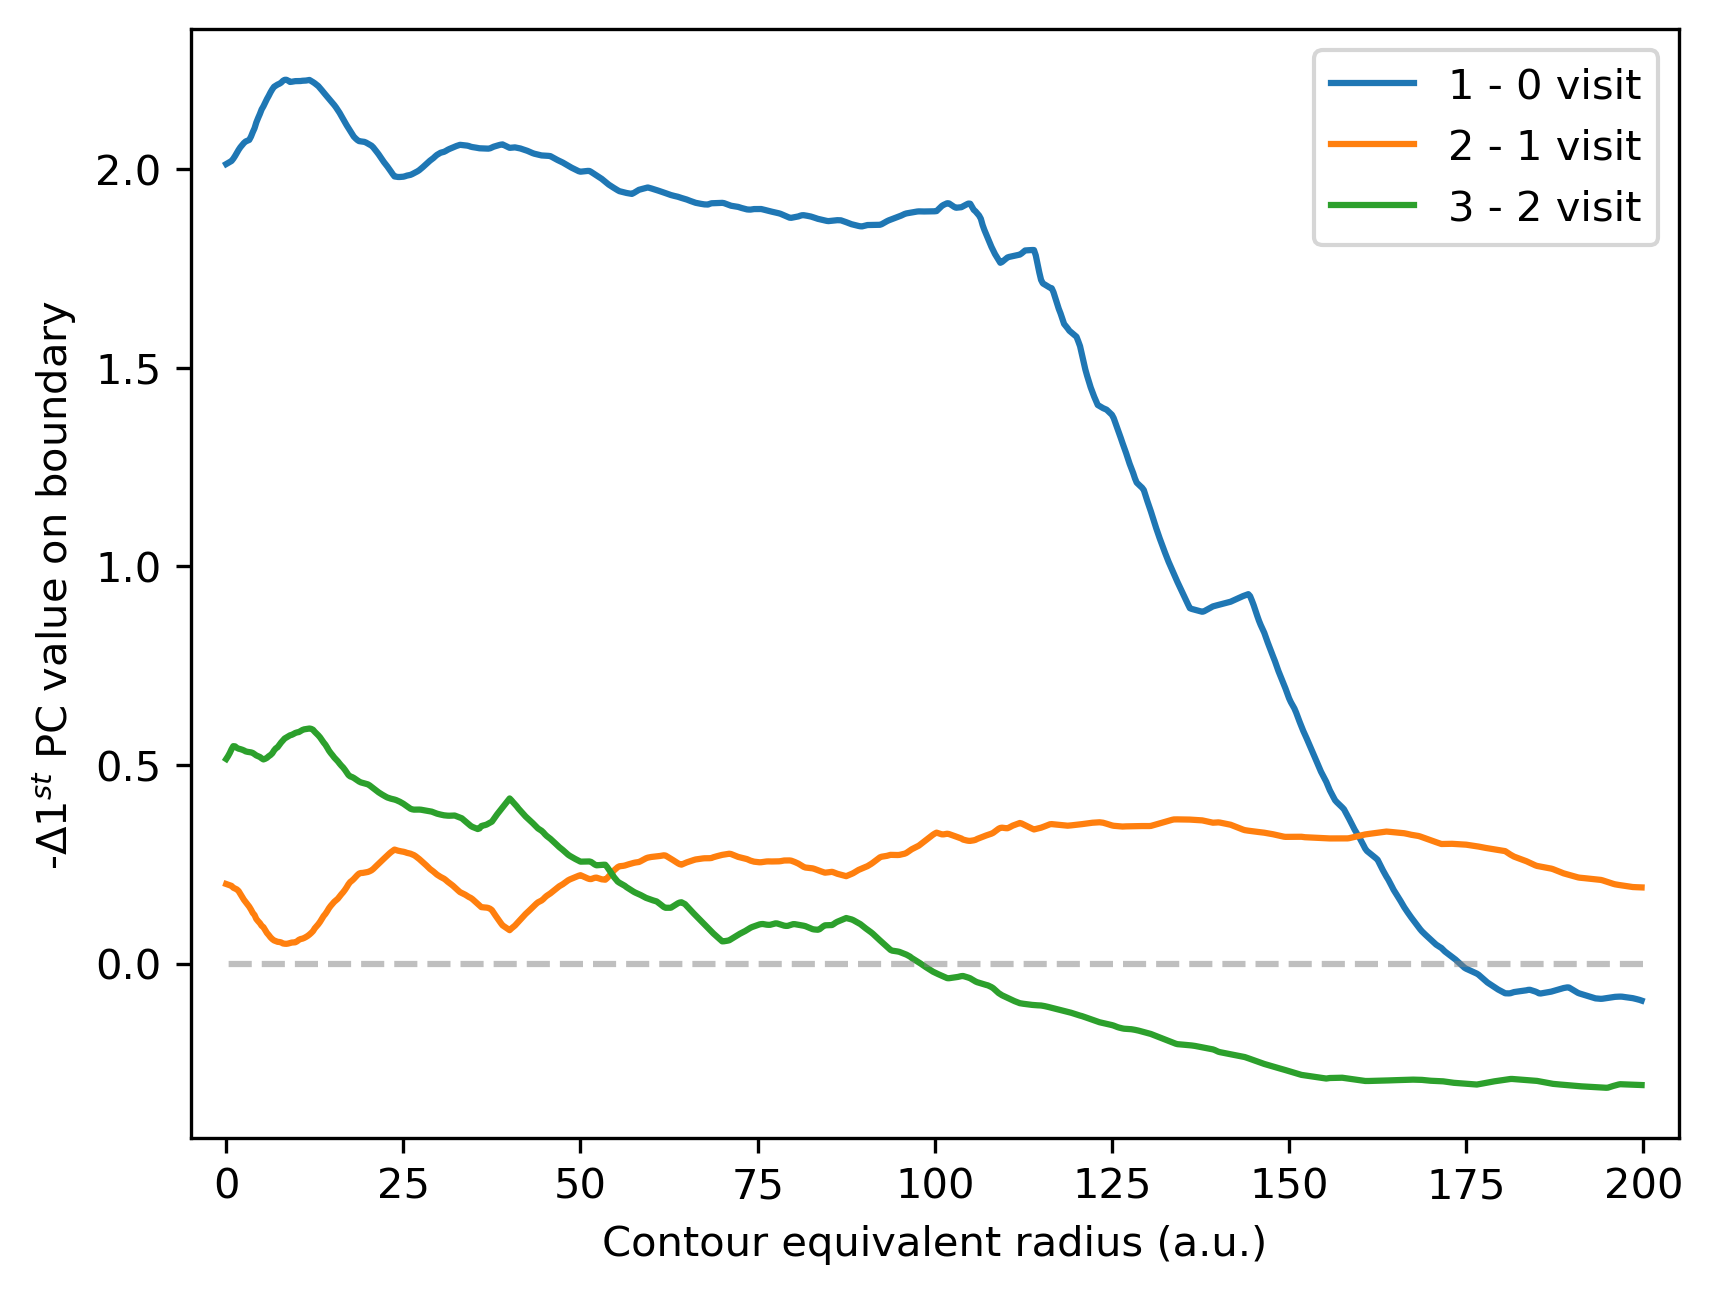

In [64]:
plt.figure(dpi = 300)
for i in range(len(names)-1):
    b = np.interp(np.arange(0, 200, 0.25), np.sqrt(np.array(area[i+1])/4/np.pi)[::-1], (mean[i+1]/skin[i+1])[::-1]) - np.interp(np.arange(0, 200, 0.25), np.sqrt(np.array(area[i])/4/np.pi)[::-1], (mean[i]/skin[i])[::-1])
    p = plt.plot(np.arange(0, 200, 0.25), 
                 -b, label = str(i+1) +' - '+ str(i) + ' visit')
plt.hlines(0, 200, 0, ls= '--', color = 'gray', alpha = 0.5)
plt.xlim(-5, 205)
plt.legend()
plt.xlabel('Contour equivalent radius (a.u.)')
plt.ylabel('-$\Delta1^{st}$ PC value on boundary')    

Text(0, 0.5, '-$\\Delta N_{boundary}$')

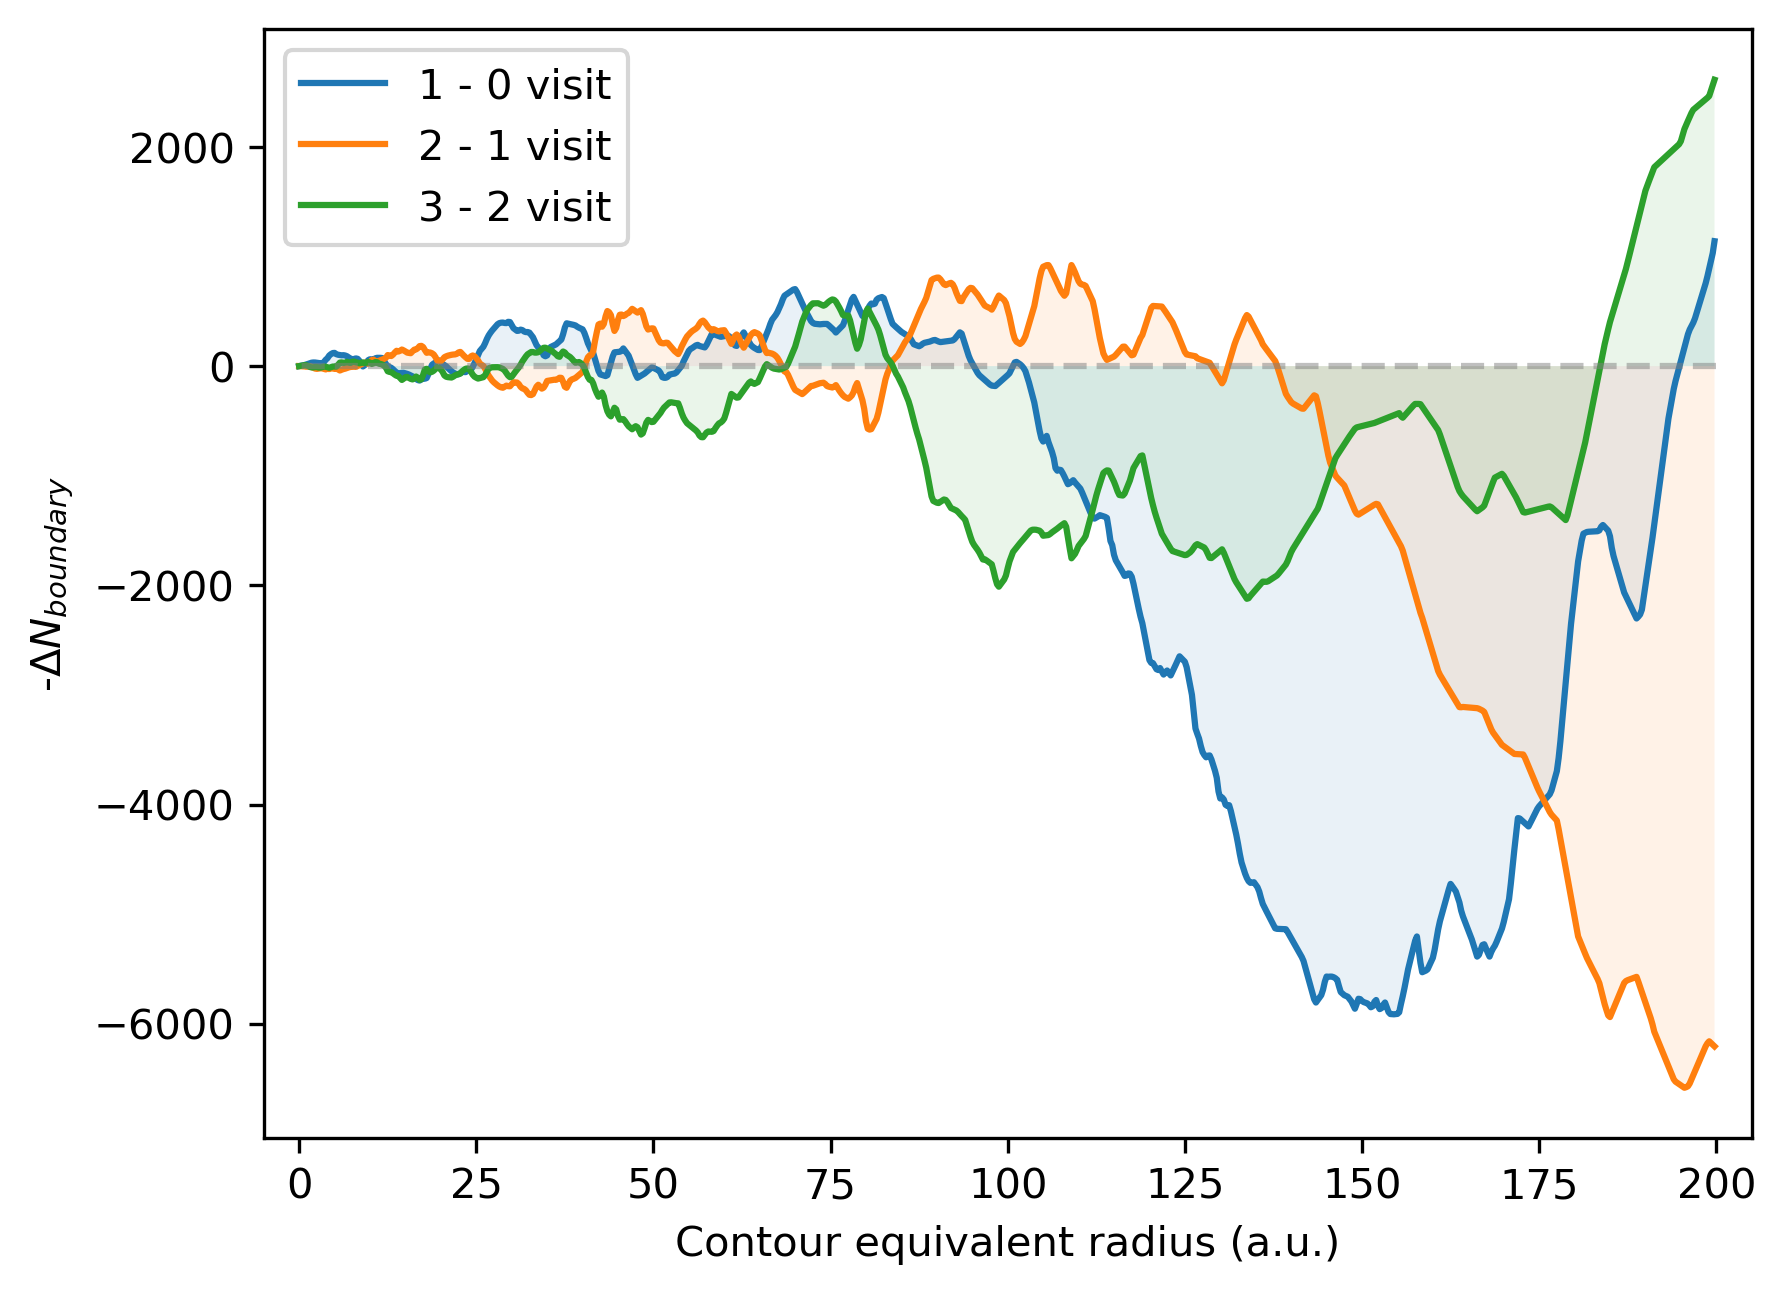

In [73]:
plt.figure(dpi = 300)
for i in range(len(names)-1):
    b = np.interp(np.arange(0, 200, 0.25), np.sqrt(np.array(area[i+1])/4/np.pi)[::-1], length[i+1][::-1]) - np.interp(np.arange(0, 200, 0.25), np.sqrt(np.array(area[i])/4/np.pi)[::-1], length[i][::-1])
    p = plt.plot(np.arange(0, 200, 0.25), 
                 -b, label = str(i+1) +' - '+ str(i) + ' visit')
    plt.fill_between(np.arange(0, 200, 0.25), -b, 0, alpha = 0.099)
plt.hlines(0, 200, 0, ls= '--', color = 'gray', alpha = 0.5)
plt.xlim(-5, 205)
plt.legend()
plt.xlabel('Contour equivalent radius (a.u.)')
plt.ylabel('-$\Delta N_{boundary}$')    

In [75]:
from scipy import interpolate

104594.0
75061.0
-157690.0


Text(0, 0.5, '-$\\Delta N_{boundary}$')

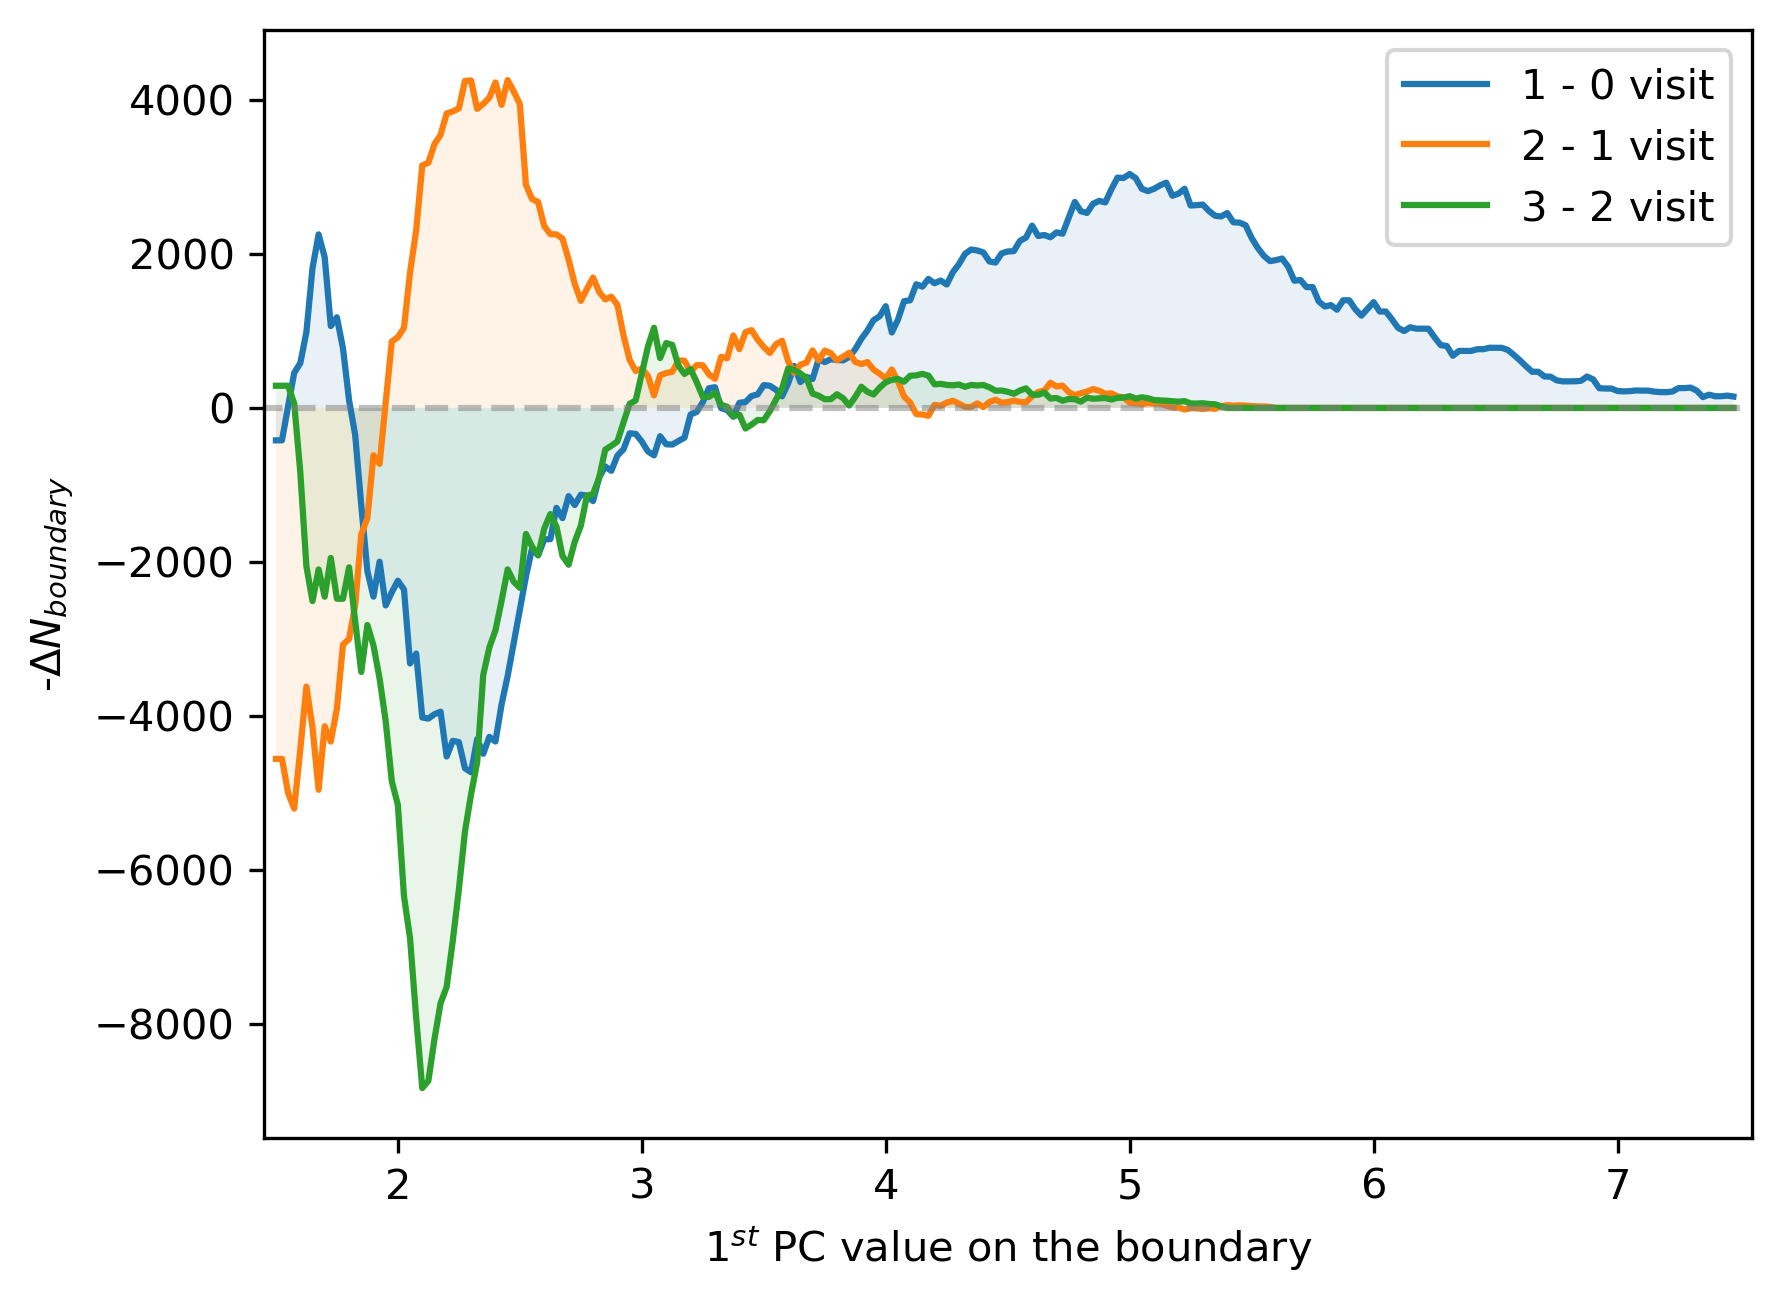

In [90]:
plt.figure(dpi = 300)
for i in range(len(names)-1):
    f = interpolate.interp1d((mean[i+1]/skin[i+1])[::-1], length[i+1][::-1], kind = 'nearest', fill_value = 'extrapolate')
    f1 = interpolate.interp1d((mean[i]/skin[i])[::-1], length[i][::-1], kind = 'nearest', fill_value = 'extrapolate')
    b = f1(np.arange(1.5, 7.5, 0.025)) - f(np.arange(1.5, 7.5, 0.025))
    p = plt.plot(np.arange(1.5, 7.5, 0.025), 
                 b, label = str(i+1) +' - '+ str(i) + ' visit')
    plt.fill_between(np.arange(1.5, 7.5, 0.025), 
                 b, 0, alpha = 0.099)

    print(sum(b))
plt.hlines(1.5, 7.5, 1.4, ls= '--', color = 'gray', alpha = 0.5)
plt.xlim(1.45, 7.55)
plt.legend()
plt.xlabel('$1^{st}$ PC value on the boundary')
plt.ylabel('-$\Delta N_{boundary}$')    